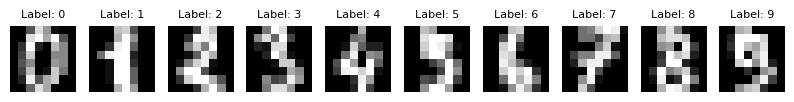

In [8]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# Load the dataset
digits = load_digits()

# Display the first 10 digits (0-9)
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {digits.target[i]}", fontsize=8)
plt.show()

In [9]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Prepare Data
X = digits.data  # 1797 samples, 64 features each
y = digits.target

# 2. Apply PCA (Linear Reduction)
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X)

# 3. Apply t-SNE (Non-linear Reduction)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_res = tsne.fit_transform(X)

# Create a DataFrame for easy plotting
df = pd.DataFrame({
    'PCA_1': pca_res[:, 0], 'PCA_2': pca_res[:, 1],
    'tSNE_1': tsne_res[:, 0], 'tSNE_2': tsne_res[:, 1],
    'digit': y.astype(str)
})

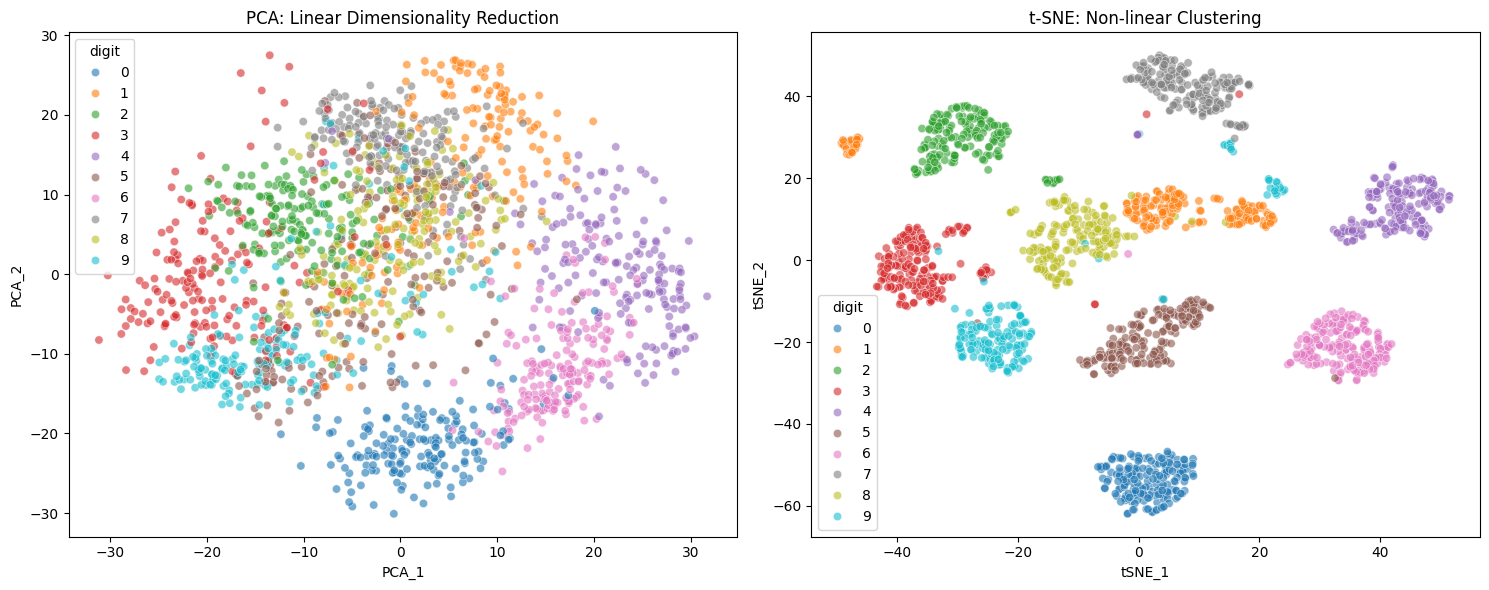

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot PCA
sns.scatterplot(x='PCA_1', y='PCA_2', hue='digit', data=df, 
                palette='tab10', ax=ax[0], legend='full', alpha=0.6)
ax[0].set_title('PCA: Linear Dimensionality Reduction')

# Plot t-SNE
sns.scatterplot(x='tSNE_1', y='tSNE_2', hue='digit', data=df, 
                palette='tab10', ax=ax[1], legend='full', alpha=0.6)
ax[1].set_title('t-SNE: Non-linear Clustering')

plt.tight_layout()
plt.show()